In [8]:
import palantir
import scanpy as sc
import pandas as pd
import os

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

# Inline plotting
%matplotlib inline

In [ ]:
ad = sc.read_h5ad('palantir/THCA_scrna_epithelial.h5ad')

/Users/yoo/opt/anaconda3/envs/scFates/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [11]:
dm_res = palantir.utils.run_diffusion_maps(ad, n_components=10, pca_key = 'X_mnn')

In [12]:
ms_data = palantir.utils.determine_multiscale_space(ad)

In [15]:
# generate neighbor draph in multiscale diffusion space
ad.obsm["X_palantir"]=ms_data.values
sc.pp.neighbors(ad,n_neighbors=30,use_rep="X_palantir")

In [16]:
# draw ForceAtlas2 embedding using 2 first PCs as initial positions
ad.obsm["X_mnn2d"]=ad.obsm["X_mnn"][:,:2]
sc.tl.draw_graph(ad,init_pos='X_mnn2d')

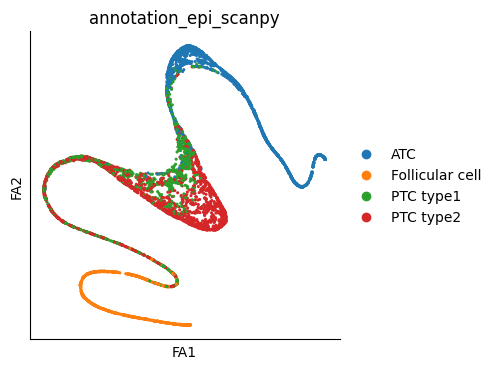

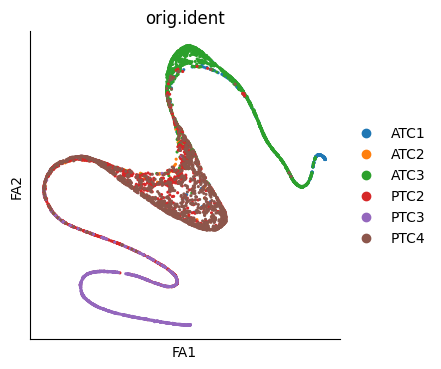

In [4]:
sc.pl.draw_graph(ad,color=["annotation_epi_scanpy"],save="20240922_epi_sub3_palantir_group_by_annotation_km.svg")
sc.pl.draw_graph(ad,color=["orig.ident"],color_map="RdBu_r")

In [19]:
imputed_X = palantir.utils.run_magic_imputation(ad)

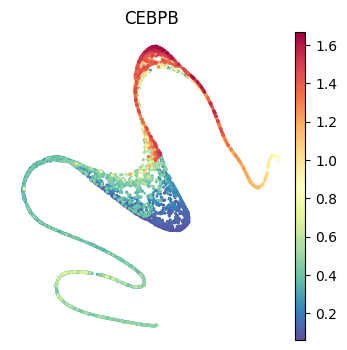

In [3]:
sc.pl.embedding(
    ad,
    basis="draw_graph_fa",
    layer="MAGIC_imputed_data",
    color=["CEBPB"],
    frameon=False,
    save="20240925_epi_sub3_palantir_CEBPB_km.svg"
)
plt.show()

In [23]:
terminal_states = pd.Series(
    ["ATC"],
    index=["ATC3_CTTAGGACAGTATGCT-1"],
)

In [ ]:
start_cell = "PTC3_AGCGTATCAATGAATG-1"
pr_res = palantir.core.run_palantir(
    ad, start_cell, num_waypoints=500, terminal_states=terminal_states) # start_cell and terminal_states determined based on monocle2 results

Sampling and flocking waypoints...
Time for determining waypoints: 0.004077033201853434 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.13931724627812703 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


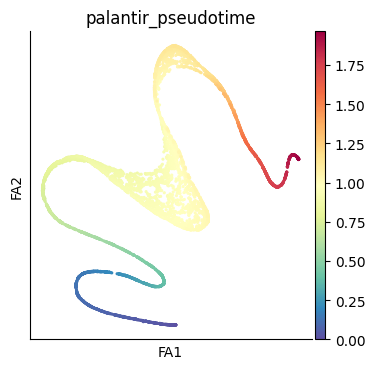

In [3]:
sc.pl.draw_graph(ad,color=["palantir_pseudotime"], save="20240411_epi_sub3_palantir_pseudotime_draw_graph.svg")

In [30]:
masks = palantir.presults.select_branch_cells(ad)

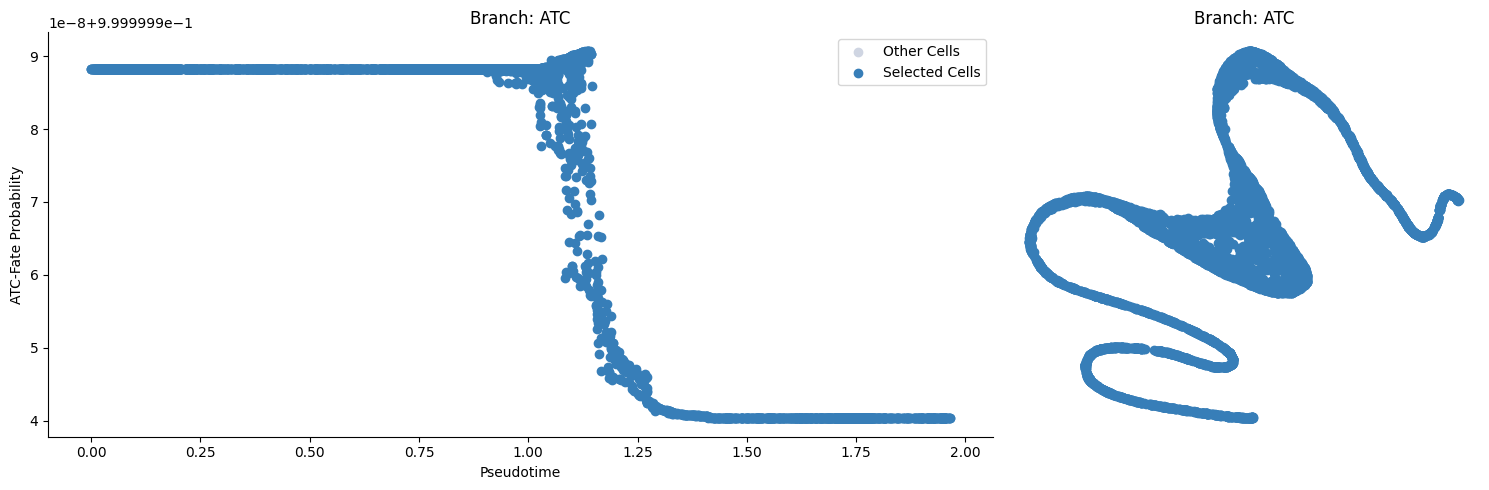

In [31]:
palantir.plot.plot_branch_selection(ad, embedding_basis = "X_draw_graph_fa")
plt.show()

In [32]:
gene_trends = palantir.presults.compute_gene_trends(
    ad,
    expression_key="MAGIC_imputed_data",
)

ATC
[2024-03-31 15:55:05,596] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (5,939) and rank = 1.0.


INFO:mellon:Using sparse Gaussian Process since n_landmarks (500) < n_samples (5,939) and rank = 1.0.


[2024-03-31 15:55:05,597] [INFO    ] Using covariance function Matern52(ls=1.0).


INFO:mellon:Using covariance function Matern52(ls=1.0).


In [ ]:
del ad.raw

In [ ]:
ad.write(filename='palantir/THCA_scrna_epithelial.h5ad')

# TFs

In [ ]:
TF = pd.read_csv('THCA_scrna_epithelial_scenic_significant_tf_including_follicular.csv', index_col=0)

In [17]:
communities_TF = palantir.presults.cluster_gene_trends(ad, "ATC", TF['x'], n_neighbors=10)

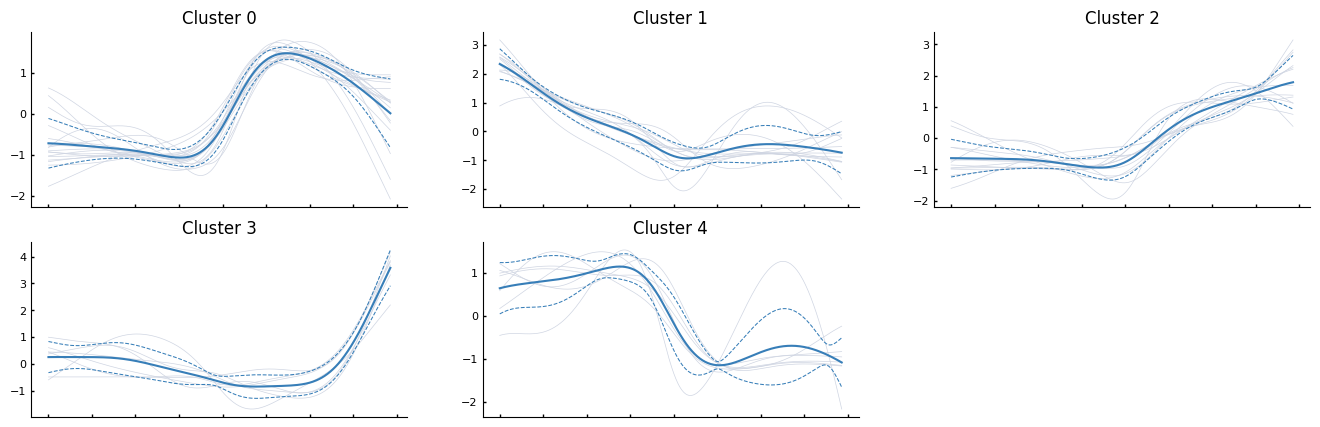

In [ ]:
palantir.plot.plot_gene_trend_clusters(ad, "ATC")
plt.savefig("20240429_epi_sub3_scenic_significant_TF_including_follicular_trend_clusters.svg",dpi=300,bbox_inches='tight')

In [19]:
communities_TF_df = pd.DataFrame({'Genes':communities_TF.index, 'Cluster':communities_TF.values})

In [20]:
communities_TF_df.to_csv('20240429_thca_scrna_epi_sub3_palantir_TF_including_follicular_gene_trend_cluster_km.csv', sep = ',')

In [21]:
TF_C1 = communities_TF_df.loc[communities_TF_df['Cluster'] == '1'].Genes.values.tolist()
TF_C4 = communities_TF_df.loc[communities_TF_df['Cluster'] == '4'].Genes.values.tolist()
TF_C0 = communities_TF_df.loc[communities_TF_df['Cluster'] == '0'].Genes.values.tolist()
TF_C2 = communities_TF_df.loc[communities_TF_df['Cluster'] == '2'].Genes.values.tolist()
TF_C3 = communities_TF_df.loc[communities_TF_df['Cluster'] == '3'].Genes.values.tolist()

In [22]:
TF_ordered = TF_C1+TF_C4+TF_C0+TF_C2+TF_C3

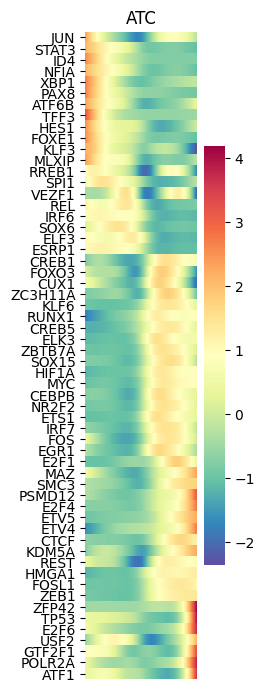

In [ ]:
palantir.plot.plot_gene_trend_heatmaps(ad, TF_ordered, basefigsize = (1.8,0.5))
plt.savefig("20240429_epi_sub3_scenic_significant_TF_including_follicular_trend_ordered_heatmap.svg",dpi=300,bbox_inches='tight')

In [ ]:
tf_ms = pd.read_csv('epi_sub3_TF_including_follicular_cluster_module_score.csv', index_col=0) # module scores calculated using AddModuleScore()

In [26]:
ad.obs["TF_cluster1"] = tf_ms.TF_cluster11.values.tolist()
ad.obs["TF_cluster4"] = tf_ms.TF_cluster41.values.tolist()
ad.obs["TF_cluster0"] = tf_ms.TF_cluster01.values.tolist()
ad.obs["TF_cluster2"] = tf_ms.TF_cluster21.values.tolist()
ad.obs["TF_cluster3"] = tf_ms.TF_cluster31.values.tolist()

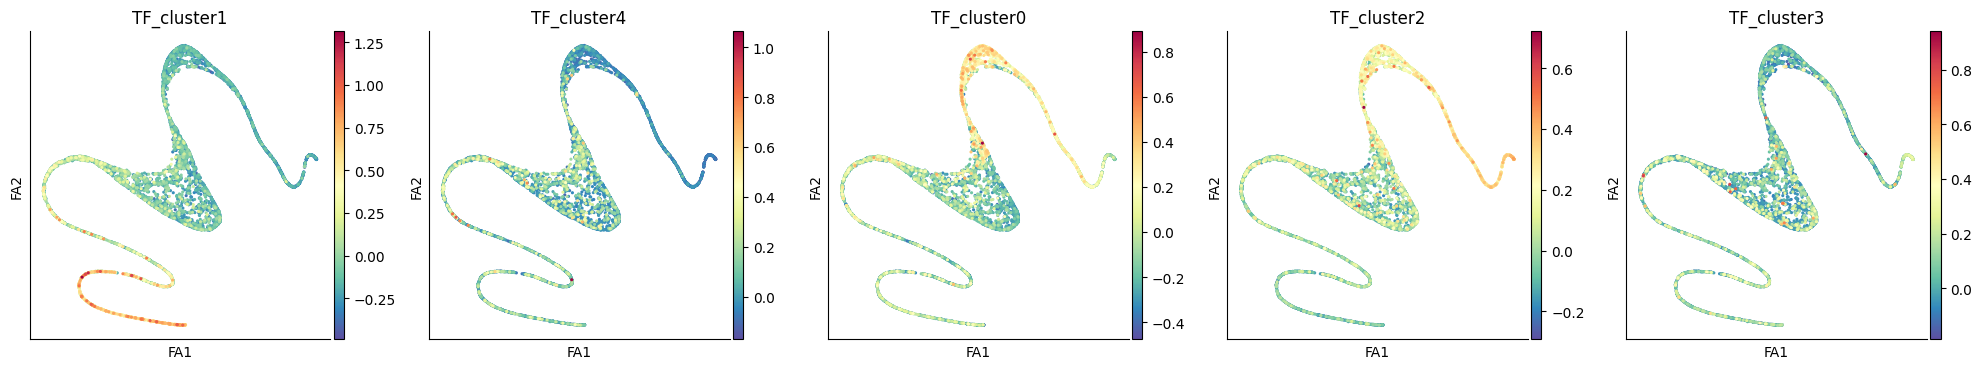

In [27]:
sc.pl.draw_graph(ad,color=["TF_cluster1","TF_cluster4","TF_cluster0","TF_cluster2","TF_cluster3"],ncols=5,save="20240429_epi_sub3_scenic_significant_TF_including_follicular_trend_cluster_module_score_featureplot.svg")

In [ ]:
ad.write(filename='palantir/THCA_scrna_epithelial_including_follicular_palantir.h5ad')